In [4]:
import pathlib
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [22]:
import pathlib
import pandas as pd

# Direct path for Kaggle environment
base_path = pathlib.Path('/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration')

# Map the train/test splits
image_paths = list(base_path.glob('**/*.jpg'))
df = pd.DataFrame({
    'path': [str(p) for p in image_paths],
    'label': [p.parent.name for p in image_paths],
    'split': ['train' if 'Train' in str(p) else 'test' for p in image_paths]
})

In [23]:
# Check unique labels and structural integrity
unique_labels = df['label'].unique()
print(f"Total Classes: {len(unique_labels)}")
print(f"Labels: {unique_labels}")

Total Classes: 9
Labels: ['pigmented benign keratosis' 'melanoma' 'vascular lesion'
 'actinic keratosis' 'squamous cell carcinoma' 'basal cell carcinoma'
 'seborrheic keratosis' 'dermatofibroma' 'nevus']


In [24]:
df

,path,label,split
0,/kaggle/input/datasets/nodoubttome/skin-cancer...,pigmented benign keratosis,test
1,/kaggle/input/datasets/nodoubttome/skin-cancer...,pigmented benign keratosis,test
2,/kaggle/input/datasets/nodoubttome/skin-cancer...,pigmented benign keratosis,test
3,/kaggle/input/datasets/nodoubttome/skin-cancer...,pigmented benign keratosis,test
4,/kaggle/input/datasets/nodoubttome/skin-cancer...,pigmented benign keratosis,test
...,...,...,...
2352,/kaggle/input/datasets/nodoubttome/skin-cancer...,nevus,train
2353,/kaggle/input/datasets/nodoubttome/skin-cancer...,nevus,train
2354,/kaggle/input/datasets/nodoubttome/skin-cancer...,nevus,train
2355,/kaggle/input/datasets/nodoubttome/skin-cancer...,nevus,train


In [25]:
train_df = df[df['split'] == 'train']
dist = train_df['label'].value_counts()
print(dist)

# Calculate Imbalance Ratio
ir = dist.max() / dist.min()
print(f"Imbalance Ratio: {ir:.2f}x")

label
pigmented benign keratosis    462
melanoma                      438
basal cell carcinoma          376
nevus                         357
squamous cell carcinoma       181
vascular lesion               139
actinic keratosis             114
dermatofibroma                 95
seborrheic keratosis           77
Name: count, dtype: int64
Imbalance Ratio: 6.00x


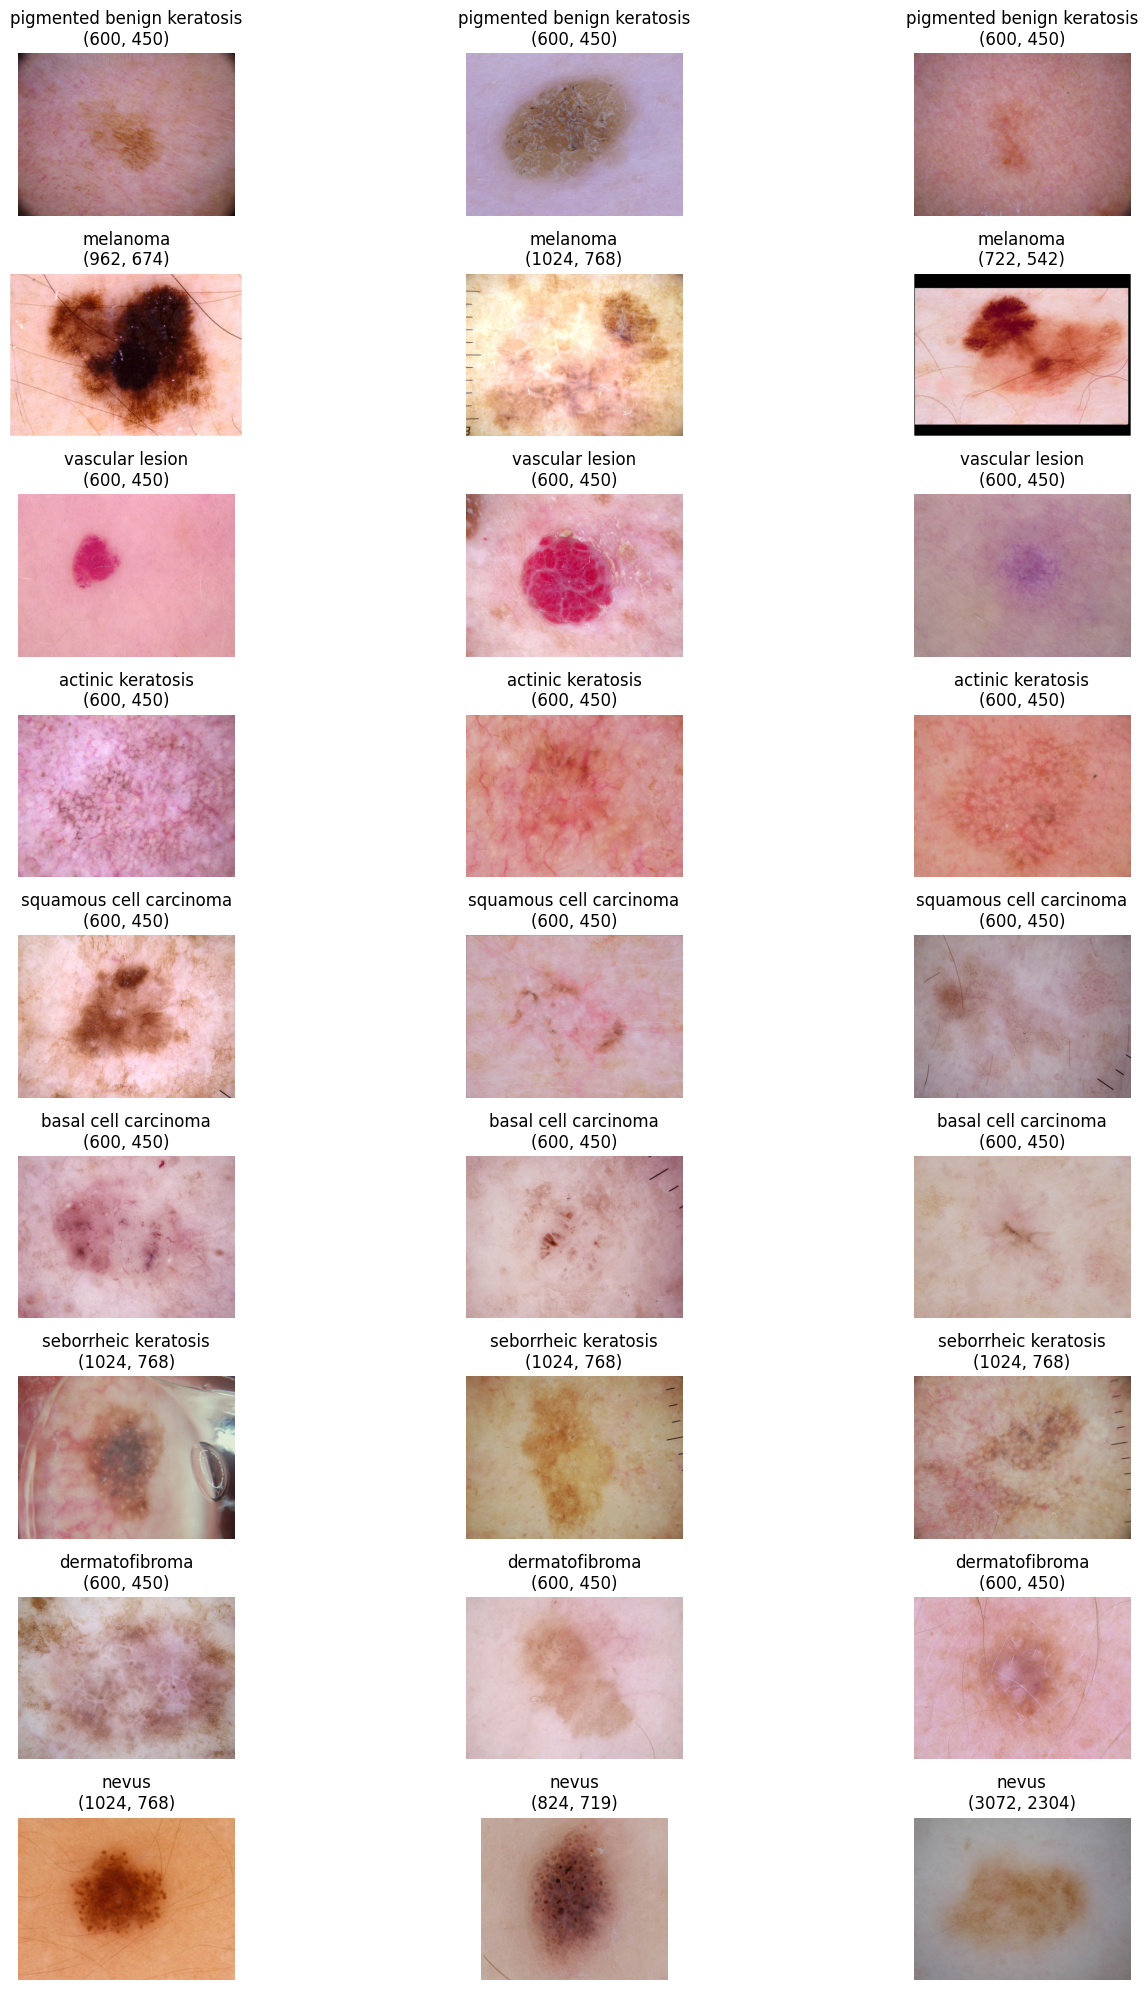

In [26]:
def inspect_lesions(df, n=3):
    classes = df['label'].unique()
    fig, axes = plt.subplots(len(classes), n, figsize=(15, 20))
    
    for i, cls in enumerate(classes):
        samples = df[df['label'] == cls].sample(n)
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row['path'])
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{cls}\n{img.size}")
            axes[i, j].axis('off')
    plt.tight_layout()

inspect_lesions(train_df)

In [1]:
import json

with open("../results/06_final_model/metrics.json", "r") as f:
    history = json.load(f)

In [2]:
epochs = [x["epoch"] for x in history]
train_loss = [x["train_loss"] for x in history]
val_loss = [x["val_loss"] for x in history]
val_f1 = [x["val_f1"] for x in history]
val_acc = [x["val_balanced_acc"] for x in history]

In [5]:
import os

save_dir = "../results/06_final_model/plots"
os.makedirs(save_dir, exist_ok=True)

# Save Loss Plot
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig(f"{save_dir}/loss.png")
plt.close()

# Save F1 Plot
plt.figure()
plt.plot(epochs, val_f1, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation Macro F1")
plt.legend()
plt.savefig(f"{save_dir}/f1.png")
plt.close()

# Save Accuracy Plot
plt.figure()
plt.plot(epochs, val_acc, label="Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Balanced Accuracy")
plt.legend()
plt.savefig(f"{save_dir}/accuracy.png")
plt.close()